In [1]:
import pandas as pd
import numpy as np

from scipy.stats import poisson

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
team_strength = pd.read_csv(
    "../data/processed/team_strength.csv",
    index_col=0
)

team_strength.head()

,elo,form_5,avg_goals_5,avg_conceded_5,avg_goal_diff_5
home_team,,,,,
Abkhazia,1575.629587,11.0,1.6,0.6,1.0
Afghanistan,1285.414066,5.0,0.4,0.8,-0.4
Albania,1589.805127,3.0,0.4,1.2,-0.8
Alderney,1184.265381,3.0,1.2,3.8,-2.6
Algeria,1770.098443,12.0,2.4,0.6,1.8


In [3]:
with open(
    "../models/home_poisson.pkl",
    "rb"
) as f:

    home_results = pickle.load(f)

with open(
    "../models/away_poisson.pkl",
    "rb"
) as f:

    away_results = pickle.load(f)

In [4]:
print(type(home_results))
print(type(away_results))

<class 'statsmodels.genmod.generalized_linear_model.GLMResultsWrapper'>
<class 'statsmodels.genmod.generalized_linear_model.GLMResultsWrapper'>


In [5]:
def predict_match(home_team, away_team):

    home = team_strength.loc[home_team]
    away = team_strength.loc[away_team]

    elo_diff = (
        home["elo"]
        - away["elo"]
    )

    home_data = pd.DataFrame({
        "const": [1],
        "elo_diff": [elo_diff],

        "home_form_5": [home["form_5"]],
        "away_form_5": [away["form_5"]],

        "home_avg_goals_5": [home["avg_goals_5"]],
        "away_avg_goals_5": [away["avg_goals_5"]],

        "home_avg_conceded_5": [home["avg_conceded_5"]],
        "away_avg_conceded_5": [away["avg_conceded_5"]],

        "home_avg_goal_diff_5": [home["avg_goal_diff_5"]],
        "away_avg_goal_diff_5": [away["avg_goal_diff_5"]]
    })

    lambda_home = home_results.predict(
        home_data
    )[0]

    away_data = pd.DataFrame({
        "const": [1],

        "away_elo_diff": [-elo_diff],

        "away_form_5": [away["form_5"]],
        "home_form_5": [home["form_5"]],

        "away_avg_goals_5": [away["avg_goals_5"]],
        "home_avg_goals_5": [home["avg_goals_5"]],

        "away_avg_conceded_5": [away["avg_conceded_5"]],
        "home_avg_conceded_5": [home["avg_conceded_5"]],

        "away_avg_goal_diff_5": [away["avg_goal_diff_5"]],
        "home_avg_goal_diff_5": [home["avg_goal_diff_5"]]
    })

    lambda_away = away_results.predict(
        away_data
    )[0]

    return {
        "home_team": home_team,
        "away_team": away_team,
        "lambda_home": float(lambda_home),
        "lambda_away": float(lambda_away)
    }

In [6]:
def simulate_match(
    home_team,
    away_team
):

    prediction = predict_match(
        home_team,
        away_team
    )

    home_goals = poisson.rvs(
        prediction["lambda_home"]
    )

    away_goals = poisson.rvs(
        prediction["lambda_away"]
    )

    return (
        home_goals,
        away_goals
    )

In [7]:
for _ in range(10):

    print(
        simulate_match(
            "Argentina",
            "Brazil"
        )
    )

(1, 1)
(3, 3)
(2, 0)
(3, 0)
(1, 1)
(2, 1)
(4, 1)
(2, 2)
(0, 1)
(2, 1)


In [8]:
def monte_carlo_match(
    home_team,
    away_team,
    simulations=10000
):

    home_wins = 0
    draws = 0
    away_wins = 0

    for _ in range(simulations):

        hg, ag = simulate_match(
            home_team,
            away_team
        )

        if hg > ag:

            home_wins += 1

        elif hg < ag:

            away_wins += 1

        else:

            draws += 1

    return {

        "home_team": home_team,
        "away_team": away_team,

        "home_win":
        home_wins / simulations,

        "draw":
        draws / simulations,

        "away_win":
        away_wins / simulations
    }

In [9]:
results = monte_carlo_match(
    "Argentina",
    "Brazil",
    simulations=10000
)

results

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_win': 0.632,
 'draw': 0.2002,
 'away_win': 0.1678}

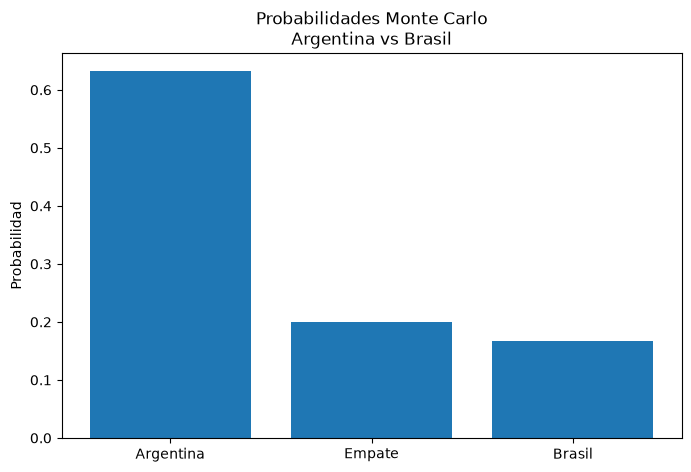

In [10]:
labels = [
    "Argentina",
    "Empate",
    "Brasil"
]

values = [
    results["home_win"],
    results["draw"],
    results["away_win"]
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    values
)

plt.title(
    "Probabilidades Monte Carlo\nArgentina vs Brasil"
)

plt.ylabel(
    "Probabilidad"
)

plt.show()

In [11]:
def match_probabilities(
    home_team,
    away_team,
    max_goals=10
):

    prediction = predict_match(
        home_team,
        away_team
    )

    home_lambda = prediction["lambda_home"]
    away_lambda = prediction["lambda_away"]

    home_win = 0
    draw = 0
    away_win = 0

    for home_goals in range(max_goals + 1):

        for away_goals in range(max_goals + 1):

            probability = (
                poisson.pmf(
                    home_goals,
                    home_lambda
                )
                *
                poisson.pmf(
                    away_goals,
                    away_lambda
                )
            )

            if home_goals > away_goals:

                home_win += probability

            elif home_goals < away_goals:

                away_win += probability

            else:

                draw += probability

    return {

        "home_team": home_team,
        "away_team": away_team,

        "home_win": home_win,
        "draw": draw,
        "away_win": away_win
    }

In [12]:
theoretical = match_probabilities(
    "Argentina",
    "Brazil"
)

theoretical

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_win': np.float64(0.6341170132048161),
 'draw': np.float64(0.20337136929326152),
 'away_win': np.float64(0.16250024957011913)}

In [13]:
team_strength.sort_values(
    "elo",
    ascending=False
).head(20)

,elo,form_5,avg_goals_5,avg_conceded_5,avg_goal_diff_5
home_team,,,,,
Argentina,1987.152787,15.0,3.4,0.2,3.2
Spain,1985.398174,11.0,2.6,0.4,2.2
France,1937.189907,12.0,2.6,1.0,1.6
Brazil,1913.438817,10.0,2.6,1.2,1.4
Portugal,1896.115815,10.0,2.6,0.8,1.8
England,1895.868743,10.0,1.2,0.4,0.8
Germany,1878.333215,15.0,3.0,0.8,2.2
Colombia,1875.313976,7.0,1.4,1.2,0.2
Netherlands,1866.208722,8.0,1.6,0.8,0.8


In [14]:
team_strength.shape

(317, 5)

In [15]:
team_strength.columns.tolist()

['elo', 'form_5', 'avg_goals_5', 'avg_conceded_5', 'avg_goal_diff_5']

In [16]:
import os

for root, dirs, files in os.walk("../data"):

    for file in files:

        print(os.path.join(root, file))

../data\interim\historical_matches.csv
../data\interim\team_matches.csv
../data\interim\worldcup2026_matches.csv
../data\processed\model_dataset.csv
../data\processed\team_strength.csv
../data\raw\results.csv


In [18]:
match_probabilities(
    "Argentina",
    "Brazil"
)

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_win': np.float64(0.6341170132048161),
 'draw': np.float64(0.20337136929326152),
 'away_win': np.float64(0.16250024957011913)}